<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17.1.2_SLR_with_SciKit-Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression with Scikit-Learn

Author: Brad Sheese

---

## Introduction

In the previous notebook (17.1.1) you wrote regression code from scratch -- computing means, distances, slopes, intercepts, residuals, and R-squared by hand. That exercise showed you *how* regression works under the hood. In this exercise we are going to see how to use the Scikit-Learn library to do the same thing with far less code. The concepts are identical; only the implementation changes.


## Imports

Notice the new import here.

We are importing the `LinearRegression` module from the `sklearn.linear_model` library.


In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


## Data: Sugar and Sweet
This is the same data we used in the previous exercise.

Execute the code below to create a dataframe from the data.


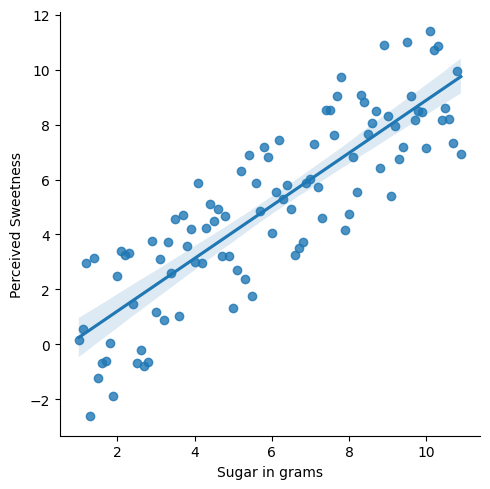

In [2]:
# make our data
sugar = np.arange(1,11,0.1)
perceived_sweet = np.array([(x/10)+random.uniform(-3,3) for x in range(100)])
studydata = pd.DataFrame(zip(sugar,perceived_sweet), columns = ['sugar','sweet'])

# plot our data
sns.lmplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()


### Transform Data into Arrays
We have our data in two series in a dataframe. We need to pull them out of the dataframe and put them into properly shaped arrays before we hand them over to SciKit-Learn. We do this by reshaping the values so they have the proper dimensions. In this case, the proper dimension of the array is n (the length of the series) by 1.

By convention in machine learning uppercase `X` is used as the variable name representing the features (aka features, predictors, independent variables), while lower case `y` is the outcome (labels, dependent variables, outcomes).


In [3]:
# index the series from the dataframe,
# get the series values,
# reshape the values into an array of dimensions (len(Series), 1)
X = studydata['sugar'].values.reshape(len(studydata['sugar']), 1)
y = studydata['sweet'].values.reshape(len(studydata['sweet']), 1)
print(X.shape)
print(y.shape)
print()

# note, we can .shape to infer the length of the array by using -1
# we get the same result but there's less to type
X = studydata['sugar'].values.reshape(-1, 1)
y = studydata['sweet'].values.reshape(-1, 1)
print(X.shape)
print(y.shape)


(100, 1)
(100, 1)

(100, 1)
(100, 1)


## Creating a Regression Model


### Step 1: Create a LinearRegression Class Instance
We need to make an instance of Sci-Kit Learn's LinearRegression class. This is an object that will encapsulate our model, perform the calculations we need, and contain our results.


In [4]:
my_regression = LinearRegression()

### Step 2: Fit the Model
We now have object called `my_regression` that is an instance of the Linear Regression class.

Calling the `.fit()` method of our object and passing it our two arrays of data will cause the object to calculate a regression line. When you are looking at the code below remember that the `X` variable represents the feature or predictor, and `y` is the outcome.

Please note that sugar is only treated as the predictor because of the way we framed our research question: "Is more sugar related to an increase in perceived sweetness?" We could frame it the other way. Our regression object doesn't care which is the X and which is the y. It will run either way.


In [5]:
my_regression.fit(X,y)

LinearRegression()

Successfully fitting the data should produce no real output. Everything worked, the calculation was done, but the results can only be seen in the object's attributes.


## Looking at Slope and Intercept

The instance of the model has now been created and fit to the data. We can see the slope and intercept of the regression by examining attributes of the model.


### Slope:

The attribute `.coef_` will output the model coefficients as an array. In this case, we get a 1 X 1 array. This coefficient represent the amount of change in the outcome (dependent variable) for one unit change in the feature.


In [6]:
my_regression.coef_


array([[0.95840969]])

To get just the coefficient value, we can index into the array. Notice the two levels of indexing here as the coefficient array is a multi-dimensional array.


In [7]:
my_regression.coef_[0,0]


np.float64(0.9584096936998354)

Or we can use the numpy array method `.item()`.


In [8]:
my_regression.coef_.item()


0.9584096936998354

### Intercept

The attribute `.intercept_` will output the model's intercept as an array. The intercept is where the linear model will cross the y-axis, which is also the expected value of y when x is zero.


In [9]:
my_regression.intercept_


array([-0.70404973])

To get just the intercept value, we can index into the array.


In [10]:
my_regression.intercept_[0]


np.float64(-0.7040497299153028)

Or, we can use the numpy array method `item()`. This method will return a single (scalar) value from an array. In this case, we can use the function without specifying an index because there is only a single item in the array.


In [11]:
my_regression.intercept_.item()


-0.7040497299153028

## Linear Regression Class  Methods

In addition to `.fit()`, the LinearRegression class also has the following methods:


`.get_params()`
* This method will return the parameters used to estimate the model. Useful if you want a reminder for how the model was built.


In [12]:
my_regression.get_params()


{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

`.predict()`
* This method can be used to pass your model a value (or values) and get back the values that your model would predict. Note that the values must be passed to the method as an array, even if you are just passing a single value.


In [13]:
sugar_single_value = np.array([[15]])

sweet_predicted_value = my_regression.predict(sugar_single_value)

print('My regression model predicts that ' + str(sugar_single_value[0,0]) +
      ' sugar would result in a perceived sweetness of ' +
      str(sweet_predicted_value[0,0].round(2)))


My regression model predicts that 15 sugar would result in a perceived sweetness of 13.67


We can also use `.predict()` to get predictions for multiple values.


In [14]:
sugar_values = np.array([[15],[20],[25]])

sweet_predicted_values = my_regression.predict(sugar_values)

sweet_predicted_values


array([[13.67209568],
       [18.46414414],
       [23.25619261]])

`.score()`
* This method returns a statistic called the coefficient of determination or R-squared ($R^2$). This score shows how well the model accounts for the data.


In [15]:
my_regression.score(X, y)


0.7286044095491702

### Understanding R-Squared

The `.score()` method returns $R^2$, the coefficient of determination. This statistic measures the proportion of variation in the outcome variable that is explained by the linear model.
* $R^2 = 1$ means the model explains 100% of the variation (perfect fit, all points on the line)
* $R^2 = 0$ means the model explains none of the variation (the line is no better than just predicting the mean)
* For simple linear regression with one predictor: $R^2 = r^2$ (the square of the correlation) Let's verify this relationship on our sugar/sweet data.


In [16]:
# R^2 from sklearn
r2_sklearn = my_regression.score(X, y)

# r^2 from correlation
r = studydata['sugar'].corr(studydata['sweet'])
r2_correlation = r ** 2

print(f"R-squared from .score(): {r2_sklearn:.4f}")
print(f"Correlation r:           {r:.4f}")
print(f"r-squared:               {r2_correlation:.4f}")
print(f"Match: {np.isclose(r2_sklearn, r2_correlation)}")
print()
print(f"Interpretation: {r2_sklearn*100:.1f}% of the variation in perceived sweetness")
print(f"is explained by sugar content in our linear model.")


R-squared from .score(): 0.7286
Correlation r:           0.8536
r-squared:               0.7286
Match: True

Interpretation: 72.9% of the variation in perceived sweetness
is explained by sugar content in our linear model.


## Plotting Our Model's Predictions


This was the visualization Seaborn made for us with a regression line as part of the visualization. Let's see if we can recreate it with predictions from our regression model.


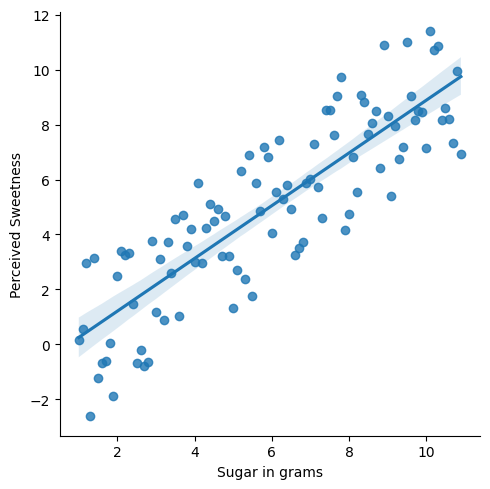

In [17]:
# plot our data
sns.lmplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()


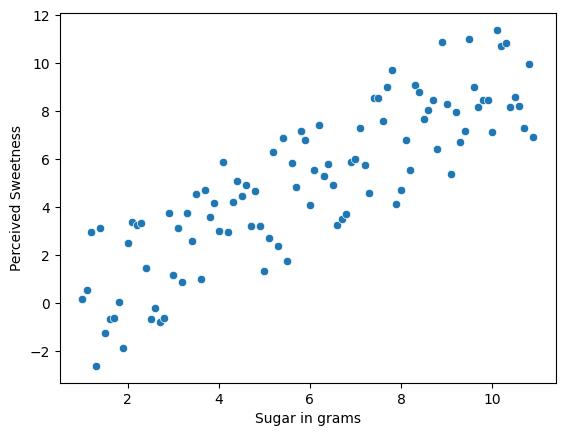

In [18]:
# first, the basic scatter plot of the data
sns.scatterplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()


Now, let's get predicted y values from our model for every value of X.


In [19]:
predicted_y = my_regression.predict(X)


Our plotting package does take arrays with complex shapes, so we need to change the shape of the X and the predicted_y arrays when we plot them. One way to do this is to use the numpy array method `.flatten()`, which takes a higher dimensional array and reduces it to a single dimensional array.


In [20]:
# flatten the arrays
X_flat = X.flatten()
y_flat = predicted_y.flatten()


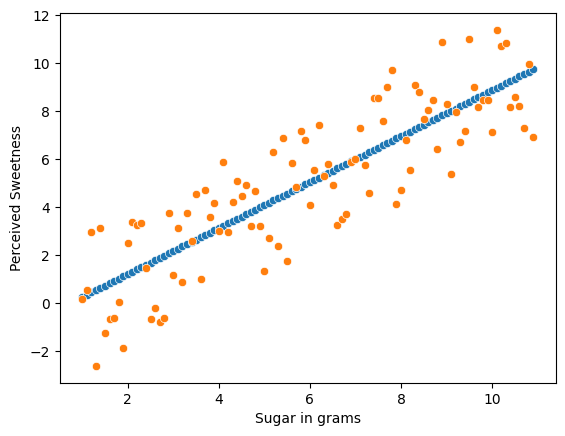

In [21]:
# plot our predictions
sns.scatterplot(x = X_flat, y = y_flat)
# plot the original data
sns.scatterplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()


That's a bit ugly. We have created a strange 'almost line' by plotting all of the x-values with the y_predicted values. To de-uglify the plot, let's use an actual line.


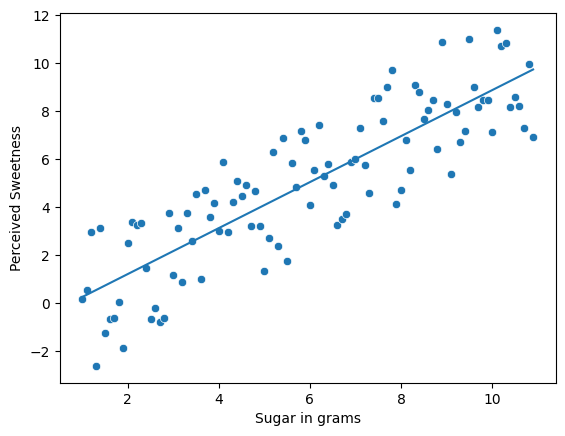

In [22]:
# get the min and max values for X
X_min = X.min()
X_max = X.max()

# use the min and max to get the predictions
predicted_y_min = my_regression.predict([[X_min]]).item()
predicted_y_max = my_regression.predict([[X_max]]).item()

# plot the line and the scatter
sns.lineplot(x = [X_min, X_max], y = [predicted_y_min, predicted_y_max])
sns.scatterplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()


## Extracting and Plotting Residuals from a sklearn Model

Now that we have a fitted sklearn model, we can extract the residuals, the differences between observed and predicted values:$$e_i = y_i - \hat{y}_i$$

In sklearn, we get predictions with `.predict()` and subtract them from the actual values.


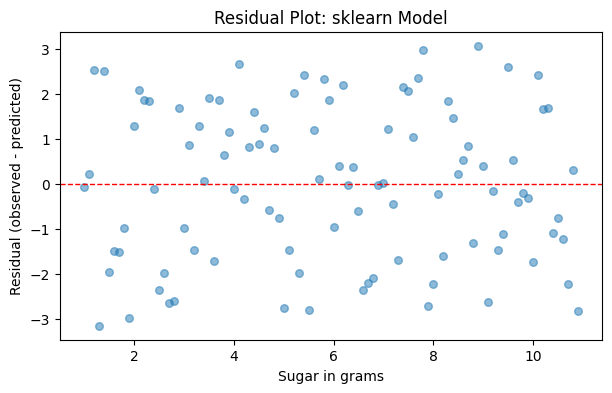

Mean residual: -0.000000 (should be ~0 for OLS)
Std residual:  1.69
Min residual:  -3.16
Max residual:  3.06


In [23]:
# Extract residuals
y_actual = y.flatten()
y_predicted = my_regression.predict(X).flatten()
residuals = y_actual - y_predicted

# Create residual plot
plt.figure(figsize=(7, 4))
plt.scatter(X_flat, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Sugar in grams')
plt.ylabel('Residual (observed - predicted)')
plt.title('Residual Plot: sklearn Model')
plt.show()

# Summary stats
print(f"Mean residual: {residuals.mean():.6f} (should be ~0 for OLS)")
print(f"Std residual:  {residuals.std():.2f}")
print(f"Min residual:  {residuals.min():.2f}")
print(f"Max residual:  {residuals.max():.2f}")


## Computing the Least Squares Line from Summary Statistics

So far we've been letting sklearn do all the work. But you can also compute the slope and intercept of the least squares line by hand using just a few summary statistics. This is useful when you only have summary data (means, standard deviations, correlation) rather than the raw observations. The formulas are:

**Slope:**
$$b_1 = \frac{s_y}{s_x} \cdot r$$

**Intercept:**$$b_0 = \bar{y} - b_1 \cdot \bar{x}$$

Where:
* $s_x$ and $s_y$ are the standard deviations of the predictor and outcome
* $r$ is the correlation between them
* $\bar{x}$ and $\bar{y}$ are the means

Let's verify this on our sugar/sweet data.


In [24]:
# Summary statistics
sugar_mean = studydata['sugar'].mean()
sweet_mean = studydata['sweet'].mean()
sugar_std = studydata['sugar'].std()
sweet_std = studydata['sweet'].std()
r = studydata['sugar'].corr(studydata['sweet'])

print(f"Sugar mean:  {sugar_mean:.4f},  std: {sugar_std:.4f}")
print(f"Sweet mean:  {sweet_mean:.4f},  std: {sweet_std:.4f}")
print(f"Correlation: {r:.4f}")
print()

# Manual slope and intercept
b1_manual = (sweet_std / sugar_std) * r
b0_manual = sweet_mean - b1_manual * sugar_mean

print(f"Manual slope:     {b1_manual:.4f}")
print(f"Manual intercept: {b0_manual:.4f}")
print()

# Compare with sklearn
b1_sklearn = my_regression.coef_.item()
b0_sklearn = my_regression.intercept_.item()

print(f"sklearn slope:     {b1_sklearn:.4f}")
print(f"sklearn intercept: {b0_sklearn:.4f}")
print()
print(f"Slope match:     {np.isclose(b1_manual, b1_sklearn)}")
print(f"Intercept match: {np.isclose(b0_manual, b0_sklearn)}")


Sugar mean:  5.9500,  std: 2.9011
Sweet mean:  4.9985,  std: 3.2574
Correlation: 0.8536

Manual slope:     0.9584
Manual intercept: -0.7040

sklearn slope:     0.9584
sklearn intercept: -0.7040

Slope match:     True
Intercept match: True


## Interpreting Slope and Intercept in Context

Numbers are easier to understand when they're tied to a real-world question. Let's look at a new dataset where the slope and intercept have clear (and not-so-clear) meanings.

### Cars: Weight vs. Fuel Efficiency
Do heavier cars get worse gas mileage?

Let's find out using the MPG dataset from seaborn.


Dataset: 392 cars

    mpg  weight  horsepower                       name
0  18.0    3504       130.0  chevrolet chevelle malibu
1  15.0    3693       165.0          buick skylark 320
2  18.0    3436       150.0         plymouth satellite
3  16.0    3433       150.0              amc rebel sst
4  17.0    3449       140.0                ford torino



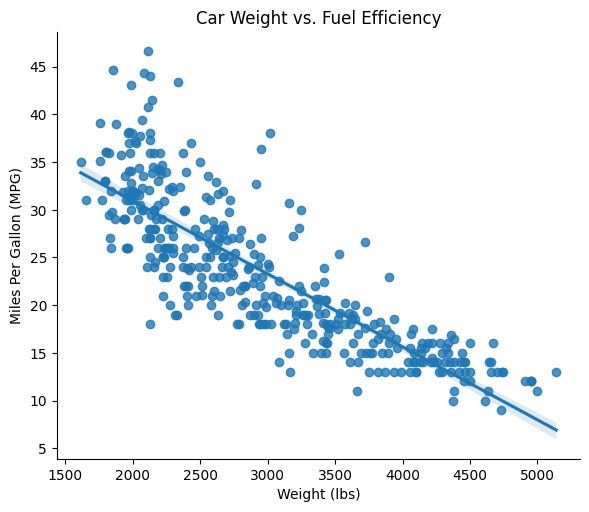

Correlation: -0.832


In [25]:
# Load MPG data
mpg = sns.load_dataset('mpg')

# Drop rows with missing horsepower (only 6 rows affected)
mpg = mpg.dropna(subset=['horsepower'])

print(f"Dataset: {len(mpg)} cars")
print()
print(mpg[['mpg', 'weight', 'horsepower', 'name']].head())
print()

# Scatterplot
sns.lmplot(x='weight', y='mpg', data=mpg, height=5, aspect=1.2)
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Car Weight vs. Fuel Efficiency')
plt.show()

print(f"Correlation: {mpg['weight'].corr(mpg['mpg']):.3f}")


In [26]:
# Fit SLR: weight -> mpg
X_mpg = mpg['weight'].values.reshape(-1, 1)
y_mpg = mpg['mpg'].values.reshape(-1, 1)

car_model = LinearRegression().fit(X_mpg, y_mpg)

slope_car = car_model.coef_.item()
intercept_car = car_model.intercept_.item()
r2_car = car_model.score(X_mpg, y_mpg)

print(f"Slope:     {slope_car:.6f}")
print(f"Intercept: {intercept_car:.2f}")
print(f"R-squared: {r2_car:.4f}")


Slope:     -0.007647
Intercept: 46.22
R-squared: 0.6926


### Interpreting the MPG Model
* **Slope (-0.0076):** For each additional pound of car weight, the expected fuel efficiency decreases by about 0.0076 mpg.
* **Scaling up:** for each additional 100 lbs, expected mpg decreases by about 0.76 mpg.
* **Intercept (46.2):** A car weighing 0 lbs is expected to get 46.2 mpg. This is clearly nonsensical. No car weighs 0 lbs, and the lightest car in our data weighs 1,613 lbs. The intercept has no practical meaning here because $x = 0$ is far outside the observed range. This illustrates an important principle: *The intercept is only meaningful if $x = 0$ is within or near the range of observed data.
* **Association vs. causation:** Heavier cars tend to get worse mileage, but we cannot claim that adding weight to a car would cause its mileage to drop based on this observational data alone.


In [27]:
# Make a sensible prediction: 3000 lb car (within data range)
weight_3000 = np.array([[3000]])
mpg_3000 = car_model.predict(weight_3000).item()

print(f"Predicted mpg for a 3,000 lb car: {mpg_3000:.1f}")
print()
print(f"Observed weight range: {int(mpg['weight'].min())} - {int(mpg['weight'].max())} lbs")
print()

# Extrapolation: 8000 lb car
weight_8000 = np.array([[8000]])
mpg_8000 = car_model.predict(weight_8000).item()
print(f"Predicted mpg for an 8,000 lb car: {mpg_8000:.1f}")
print("  ^ This is extrapolation -- the heaviest car weighs")
print(f"  {int(mpg['weight'].max())} lbs. Be cautious about predictions outside the observed range.")


Predicted mpg for a 3,000 lb car: 23.3

Observed weight range: 1613 - 5140 lbs

Predicted mpg for an 8,000 lb car: -15.0
  ^ This is extrapolation -- the heaviest car weighs
  5140 lbs. Be cautious about predictions outside the observed range.


### Quick Example: Penguins
Let's look at one more example from a different domain. The penguins dataset contains body measurements for three species of penguins. We'll predict body mass from bill depth.


Dataset: 333 penguins, 3 species



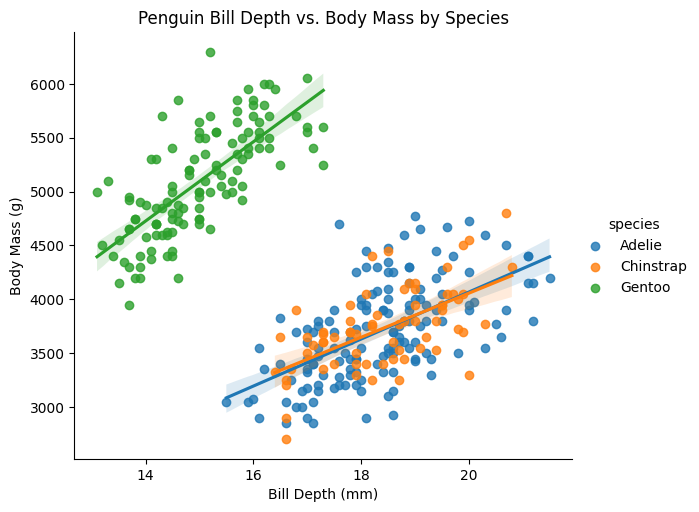

Slope:     -193.01 g per mm of bill depth
Intercept: 7520.0 g
R-squared: 0.2228


In [28]:
# Load penguins data
penguins = sns.load_dataset('penguins').dropna()

print(f"Dataset: {len(penguins)} penguins, {penguins['species'].nunique()} species")
print()

# Scatterplot colored by species
sns.lmplot(x='bill_depth_mm', y='body_mass_g', hue='species',
           data=penguins, height=5, aspect=1.2)
plt.xlabel('Bill Depth (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Penguin Bill Depth vs. Body Mass by Species')
plt.show()

# Fit model
X_peng = penguins['bill_depth_mm'].values.reshape(-1, 1)
y_peng = penguins['body_mass_g'].values.reshape(-1, 1)

peng_model = LinearRegression().fit(X_peng, y_peng)
print(f"Slope:     {peng_model.coef_.item():.2f} g per mm of bill depth")
print(f"Intercept: {peng_model.intercept_.item():.1f} g")
print(f"R-squared: {peng_model.score(X_peng, y_peng):.4f}")


### Interpreting the Penguin Model
* **Slope:** For each 1 mm increase in bill depth, expected body mass decreases by about 193 grams.
* **Intercept:** A penguin with 0 mm bill depth would weigh 7,520 grams, meaningless since the minimum bill depth is 13.1 mm.
* **R-squared:** 22.3% of the variation in body mass is explained by bill depth alone. This is modest.
* **Why the negative relationship?** The scatterplot colored by species reveals that different species cluster in different regions. The overall negative trend is partly driven by species differences, not a within-species relationship. This previews why including multiple predictors (like species) can improve our model. We will explore this idea further when we get to multiple linear regression.


## Summary: The sklearn Regression Workflow

Here's the complete workflow you've learned in this notebook:
1. **Prepare data**: `X = predictor.values.reshape(-1, 1)`, `y = outcome.values.reshape(-1, 1)`
2. **Create model**: `model = LinearRegression()`
3. **Fit**: `model.fit(X, y)`
4. **Extract parameters**: `model.coef_` (slope), `model.intercept_` (intercept), `model.score(X, y)` (R-squared)
5. **Predict**: `model.predict(new_X)`
6. **Diagnose**: `residuals = y - model.predict(X)` --> create residual plot
7. **Interpret**: slope = change in y per unit x; intercept = y when x=0 (only if meaningful)

In the next notebook (17.1.3), we'll dive deep into **residual analysis** which is the most important diagnostic tool for assessing whether a linear model is appropriatete. We will also look at how to compute and interpret correlation coefficients and R-squared more formally, including why they are "unitless" measures of relationship strength.
